In [2]:
import matplotlib as mpl

import numpy as np
import matplotlib.pyplot as plt

import matplotlib.patheffects as pe
from matplotlib.patches import Circle, RegularPolygon
from matplotlib.path import Path
from matplotlib.projections import register_projection
from matplotlib.projections.polar import PolarAxes
from matplotlib.spines import Spine
from matplotlib.transforms import Affine2D

from util import *

EXT='pdf'
DPI=400

abcd = 'abcdefghijklmnopqrstuvwxyz'

In [3]:
models = list_models()
models

['gooey', 'neongooey', 'lincs', 'moai', 'pacman', 'proteus', 'planatmo']

In [4]:
melt_curves = {model: get_melting_curves(model) for model in models}

In [5]:
def load_earth_adiabat():
    import pandas as pd
    df = pd.read_csv("melting_curves/earth_adiabat.dat", sep=r"\s+", comment='#')

    out = {}
    out["p"] = df["P[GPa]"].values 
    out["t"] = df["T[K]"].values
    out["d"] = df["d[km]"].values

    return out

earth_curve = load_earth_adiabat()

MOAI 0.95 0.95
PROTEUS 0.95 0.8899999999999999


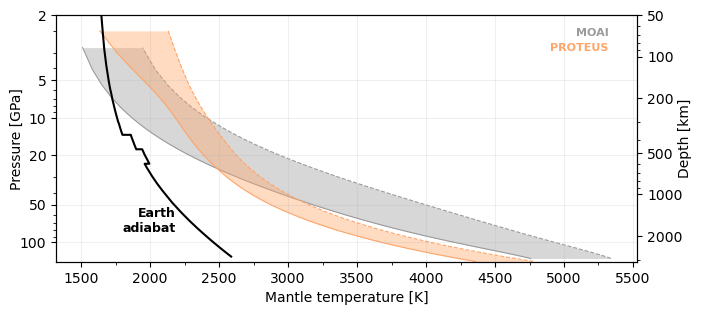

In [6]:
fig,ax = plt.subplots(figsize=(7.5,3.2))

axr = ax.twinx()


p = earth_curve['p'] 
t = earth_curve['t']
d = earth_curve['d']
# axr.plot(t, d, color='grey')
ax.plot(t, p, color='k', zorder=15)
idx = np.argmin(np.abs(p - 70))
ax.text(t[idx]-100, p[idx], "Earth\nadiabat", zorder=16,
            ha='right', va='center', color='k', fontsize=9, weight='bold')


pmin = np.amin(p)
pmax = np.amax(p) * 1.1

ax.set_yscale("log")
ax.set_ylim(top=pmin, bottom=pmax)
ax.set_yticks([pmin, 5, 10, 20, 50, 100])
ax.set_ylabel("Pressure [GPa]", labelpad=-3)

dmin = np.amin(d)
dmax = np.amax(d) * 1.1

axr.set_yscale("log")
axr.set_ylim(top=dmin, bottom=dmax)
axr.set_yticks([dmin,  100, 200, 500, 1000, 2000])
axr.set_ylabel("Depth [km]", labelpad=-3)

for axx in [ax, axr]:
    axx.yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter("%.0f"))
    axx.yaxis.set_minor_locator(mpl.ticker.LogLocator(base = 10.0, subs = np.arange(1.0, 10.0) * 0.1, numticks = 999))


im = -1
for model in models:

    curves = melt_curves[model]
    if curves is None:
        continue
    im += 1

    col = get_color(model)
    lbl = get_label(model)

    xtxt = 0.95
    ytxt = 0.95 - 0.06*im
    print(lbl, xtxt, ytxt)
    ax.text(xtxt, ytxt, lbl,  ha='right', va='top', 
            transform=ax.transAxes,
            # path_effects=[pe.Stroke(linewidth=3, foreground='w'), pe.Normal()],
            zorder=30, color=col, fontsize=8, weight='bold')

    p = curves['p'] / 1e9
    s = curves['tsol']
    l = curves['tliq']

    mask = np.argwhere((p > pmin) & (p < pmax)).flatten()
    p = p[mask]
    s = s[mask]
    l = l[mask]

    ax.plot(s, p,  ls='solid',  color=col, zorder=im, lw=0.8)
    ax.plot(l, p,  ls='dashed', color=col, zorder=im, lw=0.8)
    ax.fill_betweenx(p, s, l, color=col, alpha=0.4, linewidth=0, zorder=im)

ax.grid(alpha=0.2, zorder=0)

ax.set_xlabel("Mantle temperature [K]")
ax.xaxis.set_major_locator(mpl.ticker.MultipleLocator(500))
ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(250))

plt.show()
fig.savefig(f"out/melting_curves.{EXT}", bbox_inches='tight', dpi=DPI)
